**NIFTY50 BASELINE OHLCV - CLOSE PRICE**

In [1]:
# Numerical Computation and Data Manipulation
import numpy as np
import pandas as pd
import math

# Yahoo Finance API
import yfinance as yf

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Scaling and Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter Warnings
import warnings
warnings.filterwarnings("ignore")

# Configuration
tickers = {"Nifty 50": "^NSEI"}
horizons = {
    "5_Years": "2021-06-01",
    "10_Years": "2016-06-01",
    "20_Years": "2006-06-01"
}
end_date = "2026-06-01"

models = {
    "Naive Persistence": None,
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Elastic Net": ElasticNet(),
    "SGDRegressor": SGDRegressor(),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

In [2]:
def prep_raw_data_for_close(raw_data):
    """Prepares X (Raw OHLCV) and y (Next Day's Close)."""
    df = raw_data.copy()
    
    # Define Target: Next Day's Close Price
    df["Target"] = df["Close"].shift(-1)
    
    # Raw Features Only
    feature_cols = ["Open", "High", "Low", "Close", "Volume"]
        
    # Clean data
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    clean_df = df[feature_cols + ["Target"]].dropna()
    
    X = clean_df[feature_cols]
    y = clean_df["Target"]
    
    return X, y

In [3]:
train_results_dfs = {}
test_results_dfs = {}
plot_data_store = {} 

for company, ticker in tickers.items():
    print(f"\nDownloading data for: {company} ({ticker})")
    raw_data = yf.download(ticker, start="2005-01-01", end=end_date, progress=False)
    
    for horizon_name, start_date in horizons.items():
        horizon_raw = raw_data.loc[start_date:end_date]
        
        # Prepare data
        X, y = prep_raw_data_for_close(horizon_raw)
        
        # Chronological Split (80/20)
        split = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split], X.iloc[split:]
        y_train, y_test = y.iloc[:split], y.iloc[split:]
        
        # Setup dictionary for plotting
        dict_key = (company, horizon_name)
        plot_data_store[dict_key] = {'y_test': y_test, 'predictions': {}}
        
        current_train_metrics = []
        current_test_metrics = []
        
        for model_name, model in models.items():
                    if model_name == "Naive Persistence":
                        # Naive Persistence uses the raw, unscaled previous Close price directly
                        train_pred = X_train.iloc[:, 0].values
                        test_pred = X_test.iloc[:, 0].values
                    else:
                        # All other models use the StandardScaler pipeline
                        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
                        pipe.fit(X_train, y_train)
                        train_pred = pipe.predict(X_train)
                        test_pred = pipe.predict(X_test)
                    
                    plot_data_store[dict_key]['predictions'][model_name] = test_pred
                    
                    current_train_metrics.append({
                        "Model": model_name,
                        "Train_MAE": mean_absolute_error(y_train, train_pred),
                        "Train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
                        "Train_R2": r2_score(y_train, train_pred)
                    })
                    
                    current_test_metrics.append({
                        "Model": model_name,
                        "Test_MAE": mean_absolute_error(y_test, test_pred),
                        "Test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
                        "Test_R2": r2_score(y_test, test_pred)
                    })
                    
        # Save dataframes sorted by R2
        train_results_dfs[(company, horizon_name)] = pd.DataFrame(current_train_metrics).sort_values(by="Train_R2", ascending=False, ignore_index=True)
        test_results_dfs[(company, horizon_name)] = pd.DataFrame(current_test_metrics).sort_values(by="Test_R2", ascending=False, ignore_index=True)

print("\nExecution Complete!")



Execution Complete!


In [4]:
print("--- Train 5 Years (Close Price) ---")
display(train_results_dfs[("Nifty 50", "5_Years")])
print("\n--- Test 5 Years (Close Price) ---")
display(test_results_dfs[("Nifty 50", "5_Years")])

print("\n--- Train 10 Years (Close Price) ---")
display(train_results_dfs[("Nifty 50", "10_Years")])
print("\n--- Test 10 Years (Close Price) ---")
display(test_results_dfs[("Nifty 50", "10_Years")])

print("\n--- Train 20 Years (Close Price) ---")
display(train_results_dfs[("Nifty 50", "20_Years")])
print("\n--- Test 20 Years (Close Price) ---")
display(test_results_dfs[("Nifty 50", "20_Years")])

--- Train 5 Years (Close Price) ---


,Model,Train_MAE,Train_RMSE,Train_R2
0,DecisionTree,0.000000,0.000000,1.000000
1,XGBRegressor,27.574977,38.871632,0.999831
2,RandomForest,52.355444,71.629476,0.999426
3,GradientBoosting,97.801209,129.197615,0.998133
4,LinearRegression,126.299655,173.895206,0.996617
5,Ridge,129.182592,178.161384,0.996449
6,Lasso,129.216993,178.194741,0.996448
7,SGDRegressor,137.256085,188.108551,0.996042
8,K-Nearest Neighbors,144.555497,210.843440,0.995027
9,AdaBoostRegressor,172.209662,219.687237,0.994601



--- Test 5 Years (Close Price) ---


,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,145.978981,195.773934,0.947916
1,Lasso,151.118291,204.141665,0.943369
2,Ridge,152.309255,205.902046,0.942388
3,GradientBoosting,165.642039,214.986649,0.937192
4,SGDRegressor,163.119961,219.324435,0.934632
5,RandomForest,170.422294,229.398321,0.928489
6,Naive Persistence,191.779265,254.892847,0.911711
7,XGBRegressor,202.563504,259.515477,0.908480
8,AdaBoostRegressor,233.931276,299.883730,0.877793
9,DecisionTree,251.292162,349.242163,0.834253



--- Train 10 Years (Close Price) ---


...

,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,152.814013,215.559272,0.952744
1,Ridge,159.205570,224.146118,0.948904
2,SGDRegressor,168.481858,234.613664,0.944021
3,Lasso,173.257853,239.893478,0.941473
4,Naive Persistence,203.620503,275.571967,0.922769
5,Elastic Net,1204.387729,1228.051994,-0.533753
6,DecisionTree,1677.987105,1911.745938,-2.716912
7,RandomForest,1677.496064,1912.351071,-2.719266
8,GradientBoosting,1692.228144,1926.507013,-2.774532
9,K-Nearest Neighbors,1874.440333,2089.011267,-3.438166



--- Train 20 Years (Close Price) ---


,Model,Train_MAE,Train_RMSE,Train_R2
0,DecisionTree,0.000000,0.000000,1.000000
1,RandomForest,29.444777,42.898879,0.999870
2,XGBRegressor,45.589565,60.669898,0.999740
3,GradientBoosting,63.750663,87.045523,0.999465
4,LinearRegression,70.603241,104.504968,0.999228
5,Ridge,73.450882,107.024982,0.999191
6,K-Nearest Neighbors,73.144913,111.809590,0.999117
7,SGDRegressor,79.211665,113.698567,0.999087
8,Lasso,84.714961,120.940379,0.998967
9,Naive Persistence,96.988982,137.696658,0.998661



--- Test 20 Years (Close Price) ---


,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,130.600577,182.354412,0.995978
1,Ridge,134.144657,187.206515,0.995761
2,SGDRegressor,143.385107,197.872093,0.995264
3,Lasso,151.500778,207.473287,0.994793
4,Naive Persistence,172.754204,233.822434,0.993386
5,Elastic Net,1904.929508,1956.374297,0.537015
6,GradientBoosting,4024.473643,4849.955926,-1.845371
7,RandomForest,4062.374711,4884.628665,-1.886200
8,DecisionTree,4088.847560,4896.968628,-1.900801
9,XGBRegressor,4098.385488,4916.932457,-1.924501


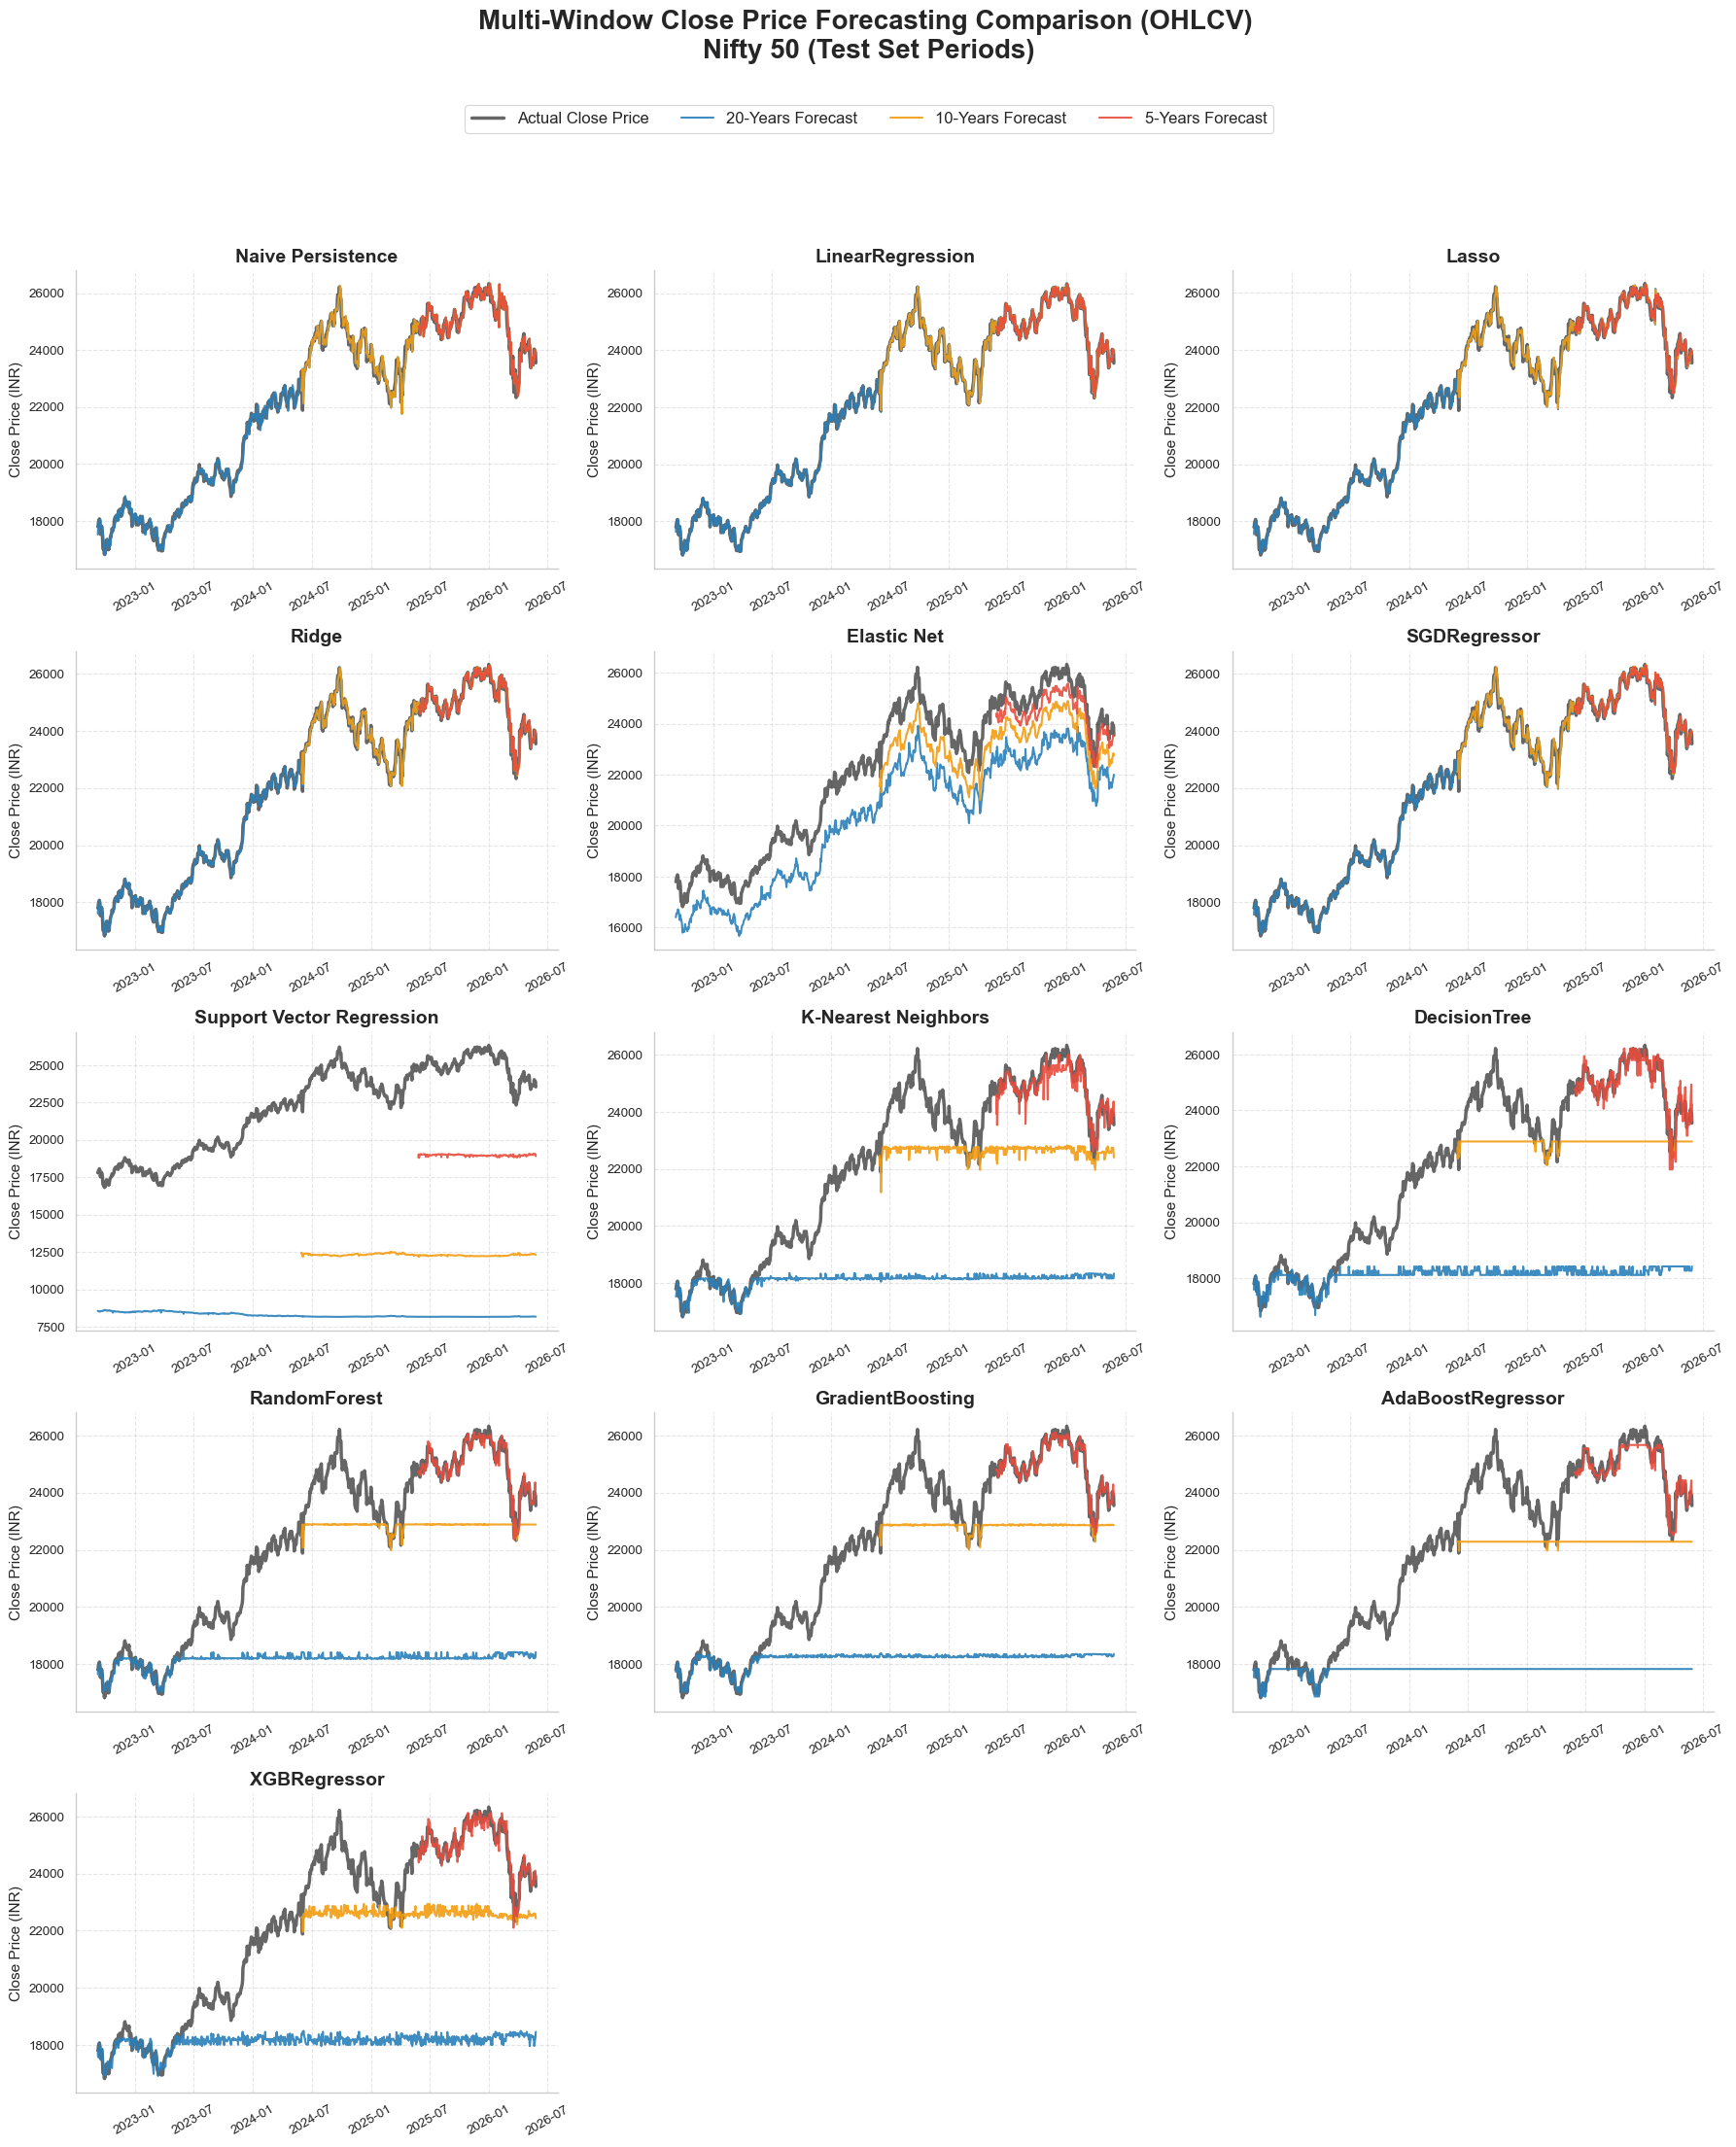

In [5]:
def plot_consolidated_predictions(company_name):
    """
    Plots Actual vs 5-Year, 10-Year, and 20-Year predictions 
    on a single graph for each model.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    
    n_models = len(models)
    n_cols = 3 
    n_rows = math.ceil(n_models / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows), sharex=False)
    axes = axes.flatten()
    
    fig.suptitle(f"Multi-Window Close Price Forecasting Comparison (OHLCV) \n{company_name} (Test Set Periods)", 
                 fontsize=20, fontweight='bold', y=0.98)
    
    colors = {
        "5_Years": "#e74c3c",  
        "10_Years": "#f39c12", 
        "20_Years": "#2980b9"  
    }
    
    # Define the order (plot longest to shortest so shorter lines render on top)
    horizon_order = ["20_Years", "10_Years", "5_Years"]
    
    for i, model_name in enumerate(models.keys()):
        ax = axes[i]
        
        # 1. Plot the Actual Prices (Using the longest 20-year test set as the baseline)
        key_20 = (company_name, "20_Years")
        if key_20 in plot_data_store:
            y_actual_20 = plot_data_store[key_20]['y_test']
            ax.plot(y_actual_20.index, y_actual_20.values, color="black", 
                    linewidth=2.5, label="Actual Close Price", alpha=0.6)
            
        # 2. Loop through horizons and plot the predictions
        for horizon_name in horizon_order:
            key = (company_name, horizon_name)
            if key not in plot_data_store: 
                continue
                
            y_test = plot_data_store[key]['y_test']
            y_pred = plot_data_store[key]['predictions'][model_name]
            
            # Create a pandas Series to align the predictions with the real dates
            pred_series = pd.Series(y_pred, index=y_test.index)
            
            label_name = horizon_name.replace("_", "-") + " Forecast"
            ax.plot(pred_series.index, pred_series.values, color=colors[horizon_name], 
                    linewidth=1.5, label=label_name, alpha=0.9)
            
        # Formatting the subplot
        ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
        ax.set_ylabel("Close Price (INR)", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Make the x-axis dates readable
        ax.tick_params(axis='x', rotation=30)
        sns.despine(ax=ax)
        
    # Remove any empty subplots if the grid isn't perfectly filled
    for j in range(n_models, len(axes)): 
        fig.delaxes(axes[j])
        
    # Extract handles for a single master legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), 
               ncol=4, frameon=True, fontsize=12)
    
    # Adjust layout to make room for the master title and legend
    plt.tight_layout(rect=[0, 0, 1, 0.91])
    
    # Save the figure in high-res for your paper before showing it
    plt.savefig(f"{company_name}_close_baseline_ohlcv_performance_forecast.png", dpi=300, bbox_inches='tight')
    plt.show()

# Execute the visualization
plot_consolidated_predictions("Nifty 50")